In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulhasibuddin/uc-merced-land-use-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/uc-merced-land-use-dataset


In [4]:
# LAB 4: Image Classification Using Deep Features (VGG16 & ResNet50)

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess


In [5]:
dataset_path = "/kaggle/input/uc-merced-land-use-dataset/UCMerced_LandUse/Images"

images = []
labels = []

for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_dir):
        continue
    
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue
        
        img = cv2.resize(img, (224, 224))
        
        images.append(img)
        labels.append(class_name)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    np.array(images),
    np.array(labels),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [7]:
def extract_features(model_name, X):
   
    if model_name == 'vgg16':
        base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
        preprocess = vgg_preprocess
    elif model_name == 'resnet50':
        base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
        preprocess = resnet_preprocess
    else:
        raise ValueError("Model must be 'vgg16' or 'resnet50'")

    features = []
    for img in X:
        img_array = np.expand_dims(img.astype('float32'), axis=0)
        img_array = preprocess(img_array)
        feat = base_model.predict(img_array, verbose=0)
        features.append(feat.flatten())
    
    return np.array(features)


In [8]:
print("Extracting VGG16 features:")
X_train_vgg = extract_features('vgg16', X_train)
X_test_vgg = extract_features('vgg16', X_test)

print("Extracting ResNet50 features:")
X_train_resnet = extract_features('resnet50', X_train)
X_test_resnet = extract_features('resnet50', X_test)


Extracting VGG16 features:


I0000 00:00:1762093438.847369      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


I0000 00:00:1762093444.886374     102 service.cc:148] XLA service 0x7948f0003bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762093444.887212     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762093445.007298     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762093446.496248     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Extracting ResNet50 features:
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [9]:
print("Training SVM (VGG16 features):")
svm_vgg = SVC(kernel='linear', probability=True)
svm_vgg.fit(X_train_vgg, y_train)

print("Training SVM (ResNet50 features):")
svm_resnet = SVC(kernel='linear', probability=True)
svm_resnet.fit(X_train_resnet, y_train)

Training SVM (VGG16 features):
Training SVM (ResNet50 features):


SVC(kernel='linear', probability=True)

In [10]:
y_pred_vgg = svm_vgg.predict(X_test_vgg)
acc_vgg = accuracy_score(y_test, y_pred_vgg)
print(f"VGG16 Feature Accuracy: {acc_vgg:.4f}")

y_pred_resnet = svm_resnet.predict(X_test_resnet)
acc_resnet = accuracy_score(y_test, y_pred_resnet)
print(f"ResNet50 Feature Accuracy: {acc_resnet:.4f}")


VGG16 Feature Accuracy: 0.9262
ResNet50 Feature Accuracy: 0.9690


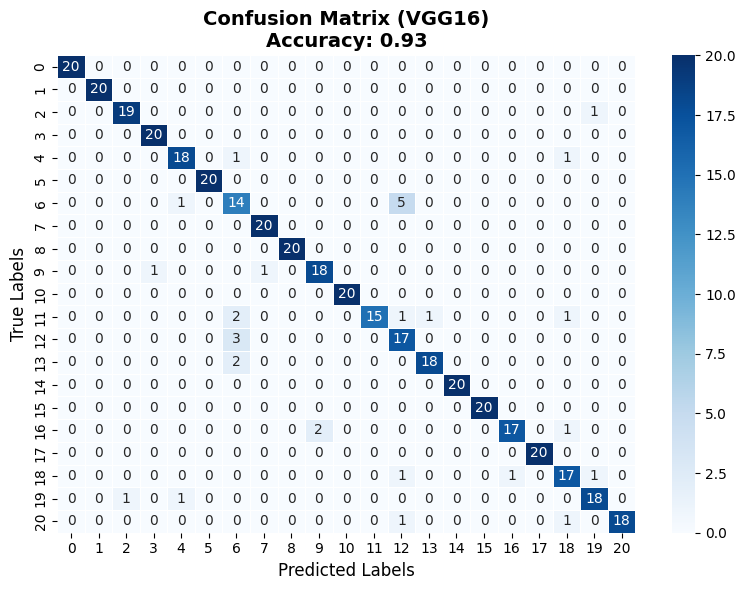

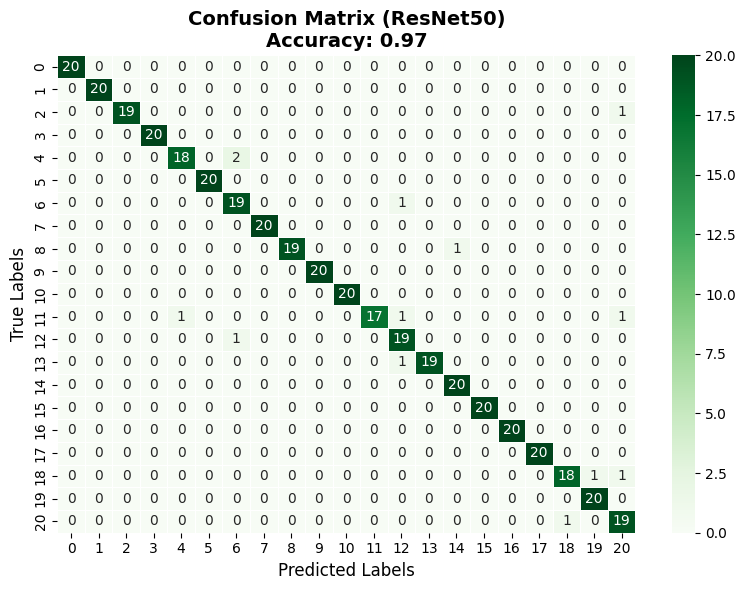

In [12]:
plt.figure(figsize=(8, 6))
cm_vgg = confusion_matrix(y_test, y_pred_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5)
plt.title(f"Confusion Matrix (VGG16)\nAccuracy: {acc_vgg:.2f}", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
cm_resnet = confusion_matrix(y_test, y_pred_resnet)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', cbar=True, linewidths=0.5)
plt.title(f"Confusion Matrix (ResNet50)\nAccuracy: {acc_resnet:.2f}", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()

